In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans

In [2]:
#read csv files
train_df = pd.read_csv('cleaned_train.csv')
test_df = pd.read_csv('cleaned_test.csv')

#**Feature Engineering**

Feature scaling using Robust scaling

In [3]:
#Robust scaling for train data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
train_df[['luxury_sales', 'fresh_sales', 'dry_sales']] = scaler.fit_transform(train_df[['luxury_sales', 'fresh_sales', 'dry_sales']])
train_df

,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_category
0,Kelaniya,-0.449398,-0.515247,0.291511,4.0
1,Moratuwa,-0.111417,-0.455032,0.424636,1.0
2,Wattala,0.509227,-0.371672,1.010734,4.0
3,Wattala,0.496846,-0.320459,1.000354,4.0
4,Kelaniya,0.559509,-0.255133,1.027203,4.0
...,...,...,...,...,...
771203,Gampaha,1.934375,0.106032,-0.051681,3.0
771204,Katunayake,3.890617,0.435659,0.474532,3.0
771205,Colombo,3.025112,0.289552,0.175634,3.0
771206,Kandy,4.082381,0.584923,0.412231,3.0


In [4]:
#Robust scaling for test data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
test_df[['luxury_sales', 'fresh_sales', 'dry_sales']] = scaler.fit_transform(test_df[['luxury_sales', 'fresh_sales', 'dry_sales']])
test_df

,outlet_city,luxury_sales,fresh_sales,dry_sales
0,Batticaloa,0.857036,0.041934,1.631142
1,Batticaloa,-0.003678,-0.156127,1.057114
2,Batticaloa,-0.770746,-0.418872,0.268686
3,Batticaloa,-0.074244,-0.206480,1.026671
4,Batticaloa,-0.606366,-0.364430,0.312032
...,...,...,...,...
40738,Wattala,1.949633,0.156016,0.029931
40739,Wattala,1.306003,-0.071869,-0.122090
40740,Wattala,1.880452,0.114705,-0.010279
40741,Wattala,2.302539,0.160306,0.103723


Feature Selection - LabelEncoder

In [5]:
#label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

#all values in 'outlet_city' are converted to string before fitting
train_df['outlet_city'] = train_df['outlet_city'].astype(str)
test_df['outlet_city'] = test_df['outlet_city'].astype(str)

#Fit on the combined unique values from both train and test data
all_cities = pd.concat([train_df['outlet_city'], test_df['outlet_city']]).unique()
label_encoder.fit(all_cities)

#Transform the columns in both dataframes
train_df['outlet_city'] = label_encoder.transform(train_df['outlet_city'])
test_df['outlet_city'] = label_encoder.transform(test_df['outlet_city'])

In [6]:
train_df

,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_category
0,12,-0.449398,-0.515247,0.291511,4.0
1,15,-0.111417,-0.455032,0.424636,1.0
2,21,0.509227,-0.371672,1.010734,4.0
3,21,0.496846,-0.320459,1.000354,4.0
4,12,0.559509,-0.255133,1.027203,4.0
...,...,...,...,...,...
771203,5,1.934375,0.106032,-0.051681,3.0
771204,11,3.890617,0.435659,0.474532,3.0
771205,2,3.025112,0.289552,0.175634,3.0
771206,10,4.082381,0.584923,0.412231,3.0


#**KNN** **Model**

In [7]:
#Check the data type of 'cluster_category'
print(train_df['cluster_category'].dtype)

float64


In [8]:
#Separate features to predict customer category and the target variable
X = train_df.drop(columns=['cluster_category'])
y = train_df['cluster_category']

In [9]:
#Train-Test Split
# Impute or remove NaN values from y before splitting
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14, stratify=y)
# Create validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=14, stratify=y_train)

In [10]:
#number of instances and input features in the training and test sets
print('X_train Instances', X_train.shape)
print('X_test Instances', X_test.shape)

X_train Instances (493572, 4)
X_test Instances (154242, 4)


In [11]:
#find the number of n_neighbors using gridsearch
from sklearn.model_selection import GridSearchCV
#Define the parameter grid for n_neighbors
param_grid = {'n_neighbors': list(range(1, 10))}

#Create and fit the GridSearchCV object
grid = GridSearchCV(KNeighborsClassifier(algorithm='auto'), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

#Get the best n_neighbors value
best_k = grid.best_params_['n_neighbors']
print(f"Best k value: {best_k}")

Best k value: 3


In [50]:
#KNN classifier
knn = KNeighborsClassifier(n_neighbors = 3)
#Fit the classifier to the data
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [13]:
#Perform predictions on the test data
y_pred=knn.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results by kNN mode
knn_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
knn_results.head()

,Actual,Predicted
413925,1.0,1.0
193845,2.0,2.0
137184,4.0,4.0
127008,4.0,4.0
187938,2.0,2.0


[[37660     1     2     1     0     1]
 [    0 30872     2     1     0     2]
 [    2     0  9769     0     1     0]
 [    1     0     2 34295     2     0]
 [    0     0     2     2  7894     3]
 [    2     0     2     1     2 33720]]


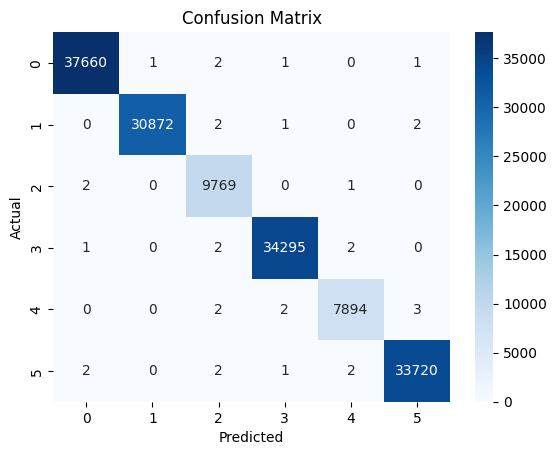

In [14]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [15]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = knn.score(X_train, y_train)
test_accuracy = knn.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = knn.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.9997925338105056
Training Accuracy: 0.9997507962364154
Testing Accuracy: 0.9997925338105056
The model is well-fitted.


In [16]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     37665
         2.0       1.00      1.00      1.00     30877
         3.0       1.00      1.00      1.00      9772
         4.0       1.00      1.00      1.00     34300
         5.0       1.00      1.00      1.00      7901
         6.0       1.00      1.00      1.00     33727

    accuracy                           1.00    154242
   macro avg       1.00      1.00      1.00    154242
weighted avg       1.00      1.00      1.00    154242



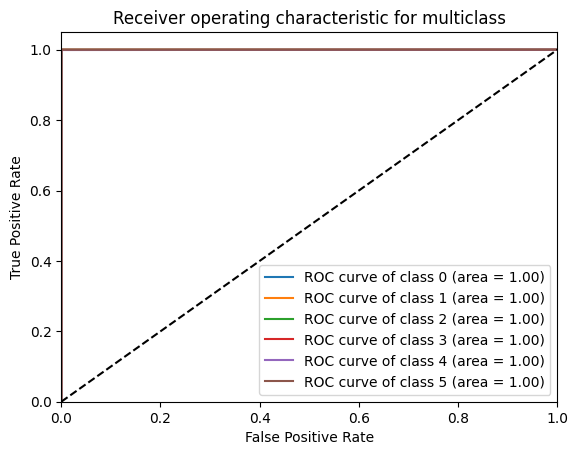

In [17]:
#ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
#Assuming y_test and y_pred are your true and predicted labels

#Binarize the output
lb = LabelBinarizer()
lb.fit(y_test)
y_test_bin = lb.transform(y_test)
y_pred_bin = lb.transform(y_pred)

#Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#Plot all ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic for multiclass")
plt.legend(loc="lower right")
plt.show()

#**Logistic Regression Model**

In [18]:
#Define features and target
features = ['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']
X = train_df[features]
y = train_df['cluster_category']

In [19]:
#Train-Test Split
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [20]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [21]:
#Perform predictions on the test data
y_pred = logreg.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results
knn_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
knn_results.head()

,Actual,Predicted
51082,4.0,4.0
350231,5.0,5.0
240496,2.0,2.0
396372,1.0,1.0
17469,4.0,4.0


[[37532     0     2   225     3     1]
 [    0 30066     1     2     2   698]
 [    1     0  7167    72  2535    40]
 [  245     1     4 33938     1     0]
 [    1     0  2807    46  5073    22]
 [    0   472     3     3     2 33277]]


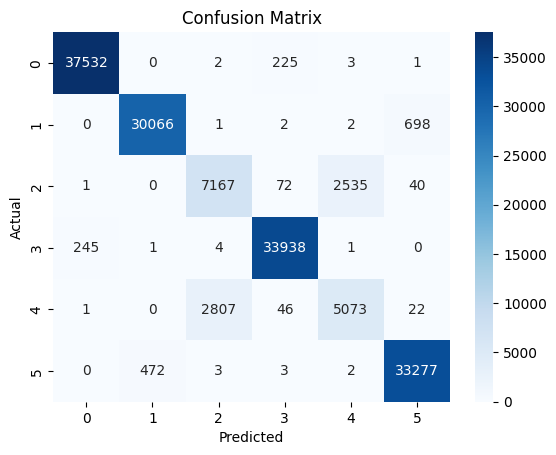

In [22]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = logreg.score(X_train, y_train)
test_accuracy = logreg.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = logreg.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.9533914238663918
Training Accuracy: 0.9545152480286564
Testing Accuracy: 0.9533914238663918
The model is well-fitted.


In [24]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99     37763
         2.0       0.98      0.98      0.98     30769
         3.0       0.72      0.73      0.72      9815
         4.0       0.99      0.99      0.99     34189
         5.0       0.67      0.64      0.65      7949
         6.0       0.98      0.99      0.98     33757

    accuracy                           0.95    154242
   macro avg       0.89      0.89      0.89    154242
weighted avg       0.95      0.95      0.95    154242



#**Decision Tree Model**

In [25]:
#Define features and target
features = ['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']
X = train_df[features]
y = train_df['cluster_category']

In [26]:
#Train-Test Split
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [27]:
#decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [28]:
#Perform predictions on the test data
y_pred = dt.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results
dt_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
dt_results.head()

,Actual,Predicted
51082,4.0,4.0
350231,5.0,5.0
240496,2.0,2.0
396372,1.0,1.0
17469,4.0,4.0


[[37707     1     3    47     3     2]
 [    2 30718     3     3     1    42]
 [    4     1  9796     0    11     3]
 [   52     5     1 34124     5     2]
 [    0     2    12     4  7927     4]
 [    1    40     1     4     2 33709]]


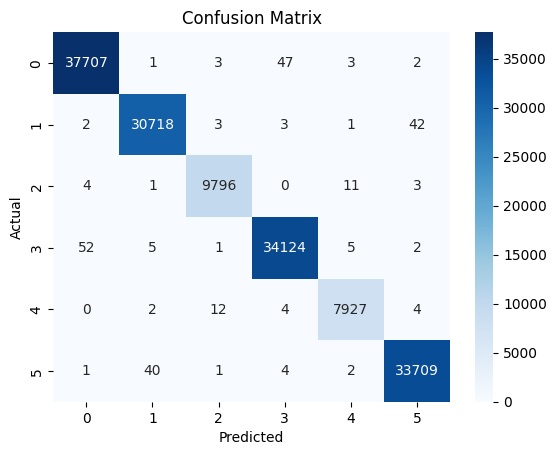

In [29]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [30]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = dt.score(X_train, y_train)
test_accuracy = dt.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = dt.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.9983078538919361
Training Accuracy: 1.0
Testing Accuracy: 0.9983078538919361
The model is well-fitted.


In [31]:
#Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     37763
         2.0       1.00      1.00      1.00     30769
         3.0       1.00      1.00      1.00      9815
         4.0       1.00      1.00      1.00     34189
         5.0       1.00      1.00      1.00      7949
         6.0       1.00      1.00      1.00     33757

    accuracy                           1.00    154242
   macro avg       1.00      1.00      1.00    154242
weighted avg       1.00      1.00      1.00    154242



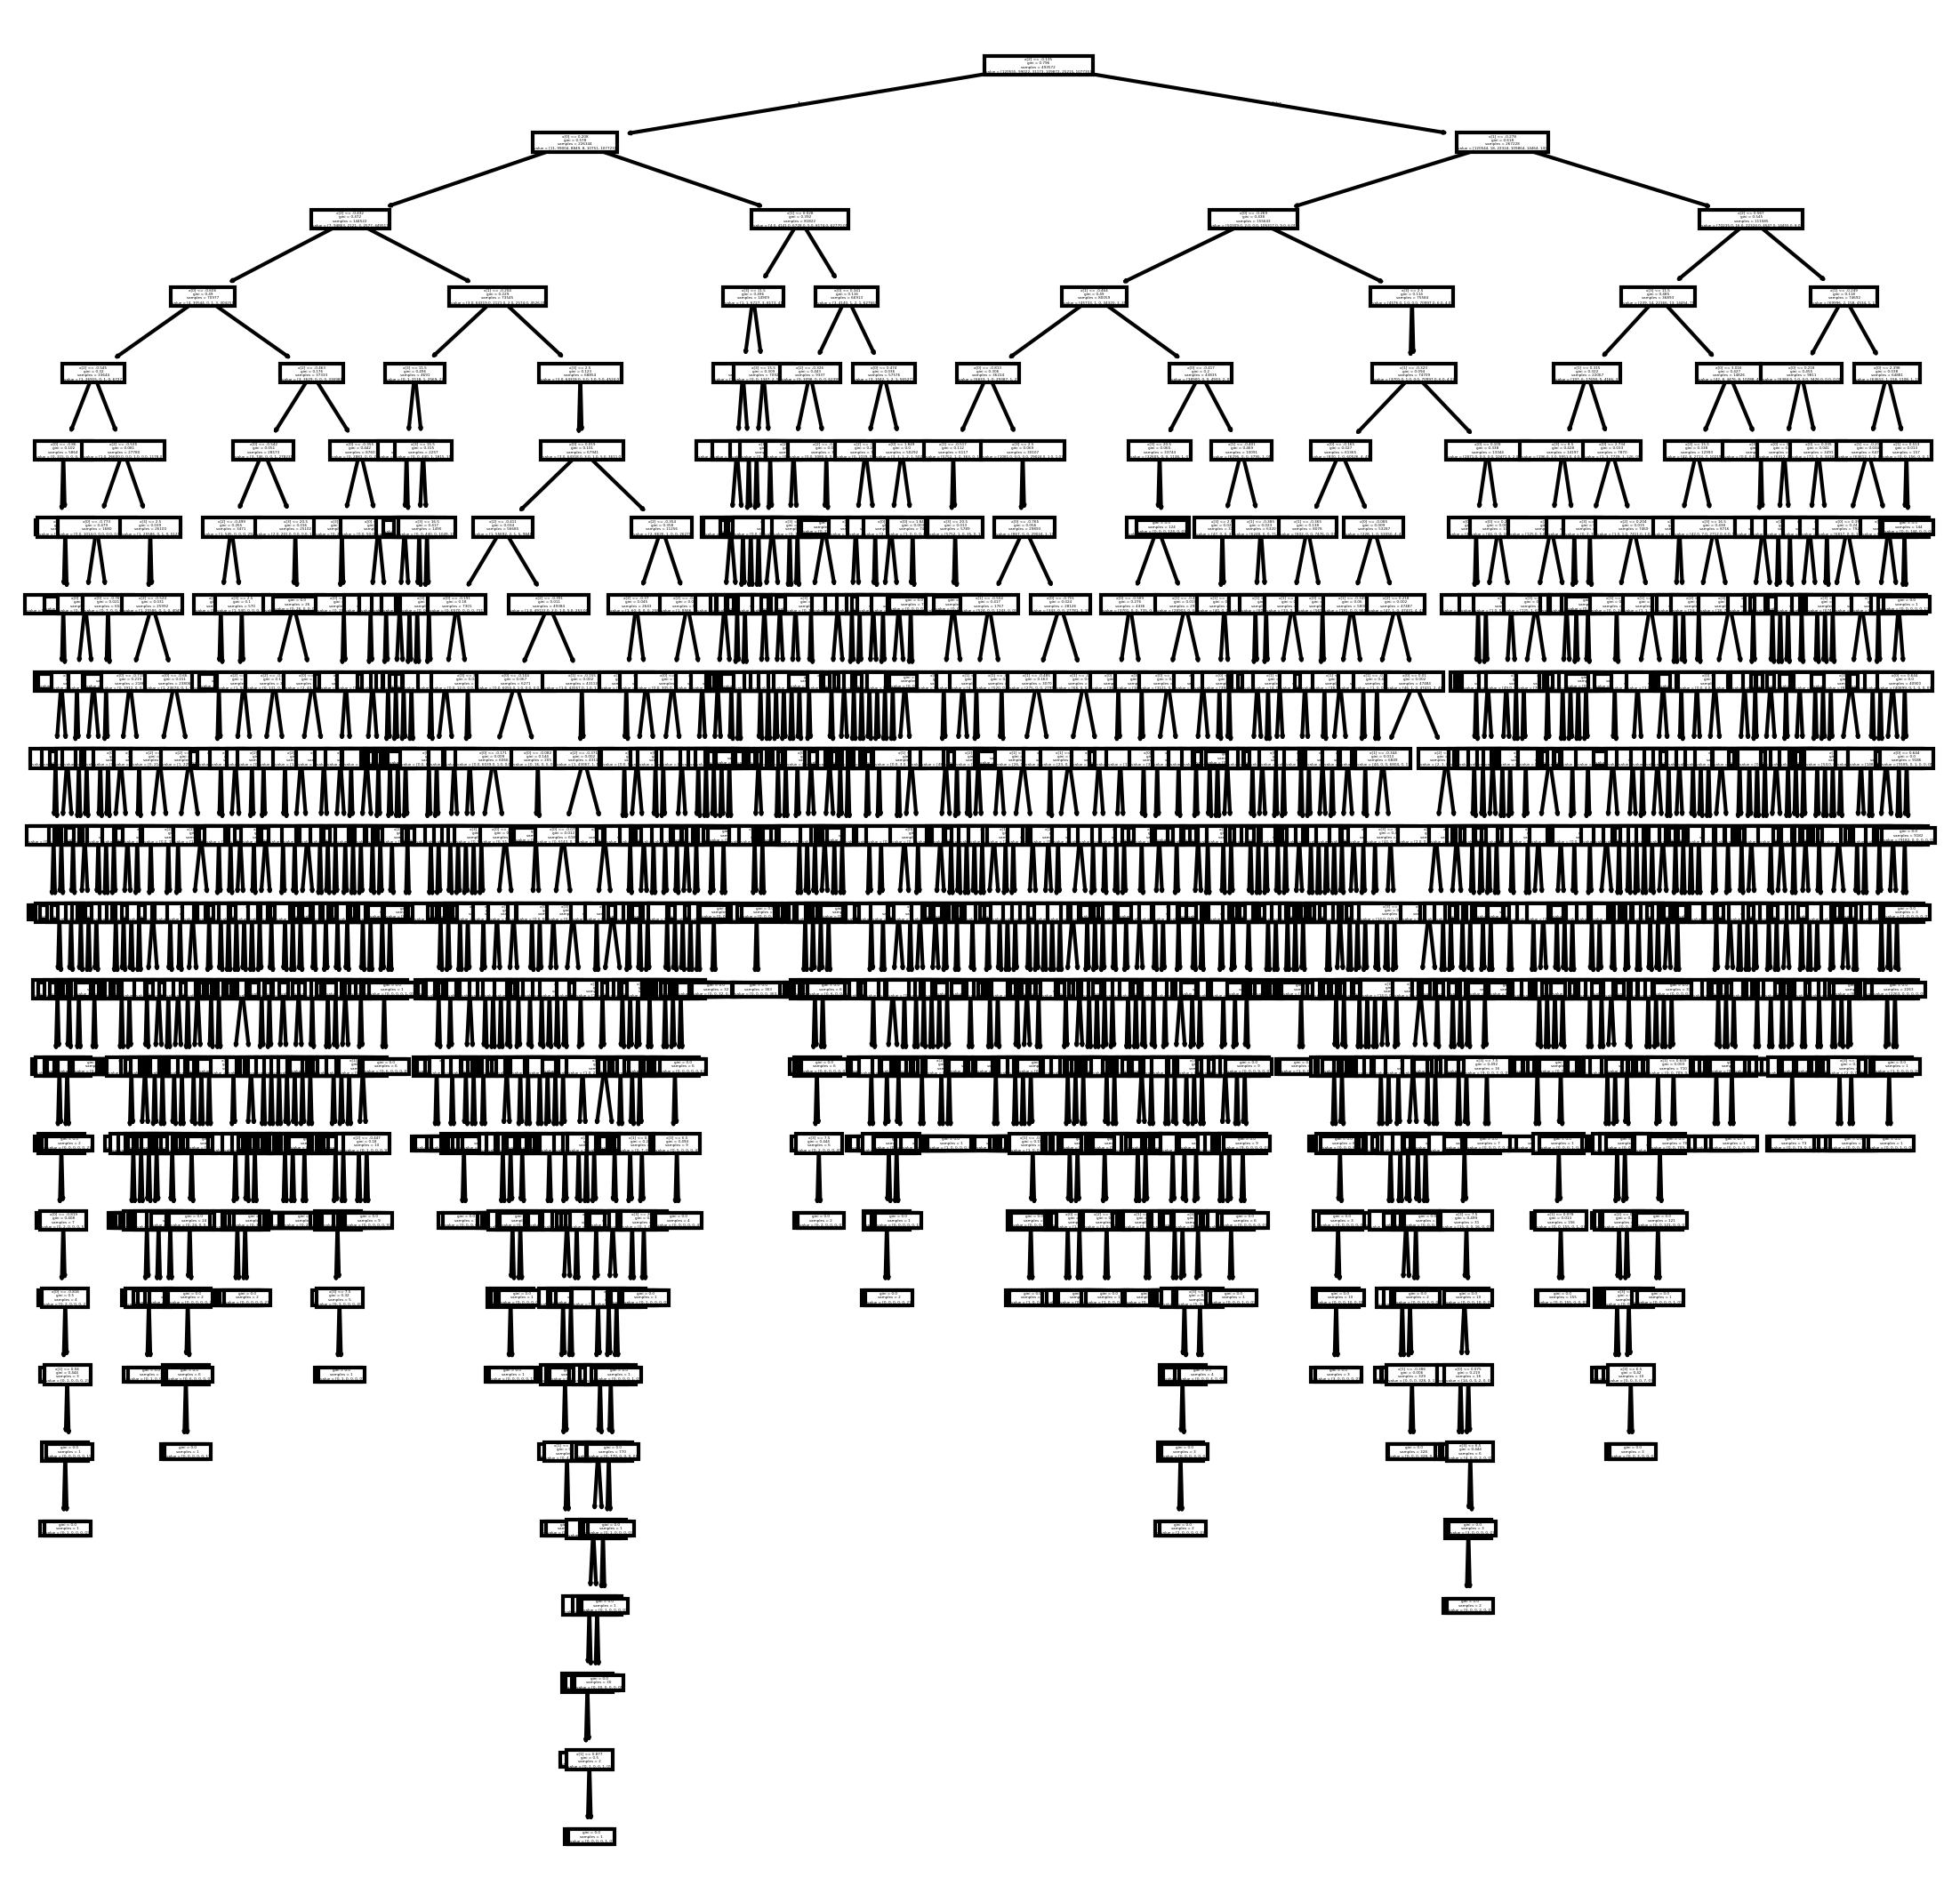

In [32]:
#decision tree diagram
import matplotlib.pyplot as plt
from sklearn import tree

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(9, 9), dpi=300)
tree.plot_tree(dt)
plt.show()

#**Random Forest Classification Model**

In [33]:
#Define features and target
features = ['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']
X = train_df[features]
y = train_df['cluster_category']

In [34]:
#Train-Test Split
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [35]:
#random forest classification
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [36]:
#Perform predictions on the test data
y_pred = rf.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results
rf_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
rf_results.head()

,Actual,Predicted
51082,4.0,4.0
350231,5.0,5.0
240496,2.0,2.0
396372,1.0,1.0
17469,4.0,4.0


[[37739     0     3    19     1     1]
 [    0 30749     1     3     1    15]
 [    3     0  9809     0     1     2]
 [   15     1     1 34170     2     0]
 [    0     0    11     3  7933     2]
 [    0    27     0     3     1 33726]]


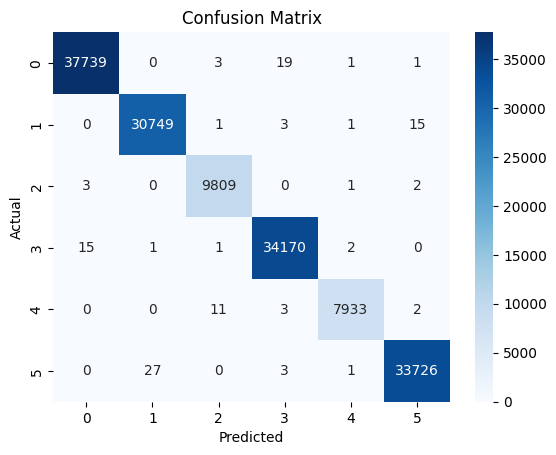

In [37]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

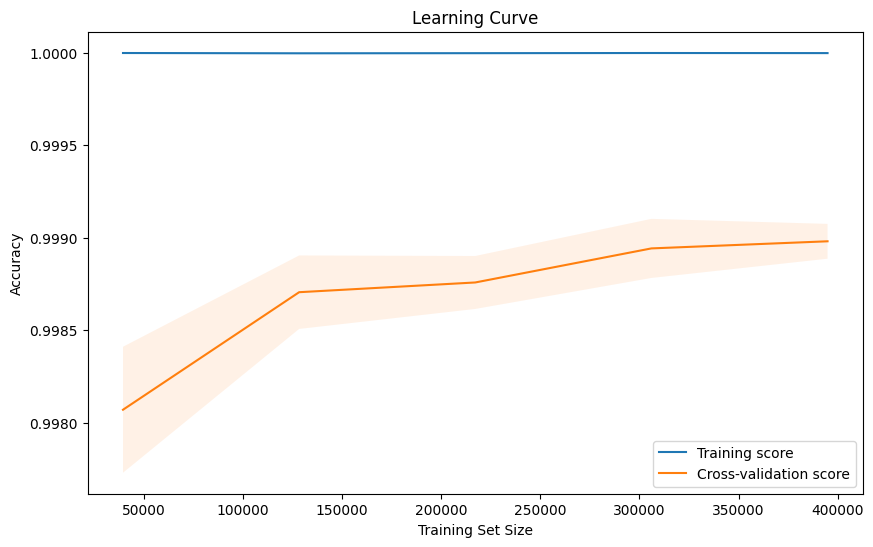

In [38]:
#plotting the learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(rf, X_train, y_train, cv=5, scoring='accuracy')
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.show()

In [39]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = rf.score(X_train, y_train)
test_accuracy = rf.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = rf.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.9992479350630827
Training Accuracy: 1.0
Testing Accuracy: 0.9992479350630827
The model is well-fitted.


In [40]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     37763
         2.0       1.00      1.00      1.00     30769
         3.0       1.00      1.00      1.00      9815
         4.0       1.00      1.00      1.00     34189
         5.0       1.00      1.00      1.00      7949
         6.0       1.00      1.00      1.00     33757

    accuracy                           1.00    154242
   macro avg       1.00      1.00      1.00    154242
weighted avg       1.00      1.00      1.00    154242



#**Gradient Boosting Model**

In [41]:
#Define features and target
features = ['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']
X = train_df[features]
y = train_df['cluster_category']

In [42]:
#Train-Test Split
y = y.fillna(y.mode()[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [43]:
#Gradient boosting model
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [44]:
#Perform predictions on the test data
y_pred = gb.predict(X_test)

#Create a dataframe for comparing the actual vs predicted results
gb_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
gb_results.head()

,Actual,Predicted
51082,4.0,4.0
350231,5.0,5.0
240496,2.0,2.0
396372,1.0,1.0
17469,4.0,4.0


[[37747     0     3    11     1     1]
 [    0 30761     1     2     3     2]
 [    5     0  9808     0     1     1]
 [    7     1     1 34177     3     0]
 [    1     0     0     3  7943     2]
 [    0     4     0     3     1 33749]]


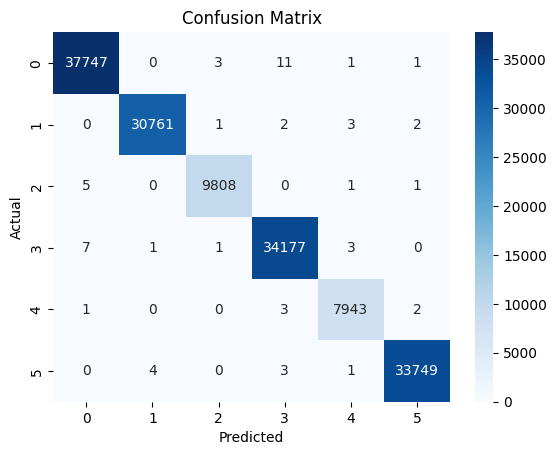

In [45]:
#confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

#plot the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [46]:
#evaluate the data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Detect overfitting or underfitting
train_accuracy = gb.score(X_train, y_train)
test_accuracy = gb.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Calculate val_accuracy
val_accuracy = gb.score(X_val, y_val)

if train_accuracy > val_accuracy + 0.005:
    print("The model is overfitting.")
elif train_accuracy < 0.90 and val_accuracy < 0.90:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Accuracy: 0.999630450849963
Training Accuracy: 0.9997082492523887
Testing Accuracy: 0.999630450849963
The model is well-fitted.


In [47]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00     37763
         2.0       1.00      1.00      1.00     30769
         3.0       1.00      1.00      1.00      9815
         4.0       1.00      1.00      1.00     34189
         5.0       1.00      1.00      1.00      7949
         6.0       1.00      1.00      1.00     33757

    accuracy                           1.00    154242
   macro avg       1.00      1.00      1.00    154242
weighted avg       1.00      1.00      1.00    154242



In [53]:
#feature importance
feature_importance = gb.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

        Feature  Importance
2     dry_sales    0.359308
1   fresh_sales    0.309604
0  luxury_sales    0.269856
3   outlet_city    0.061231


In [51]:
#which model is the best
print("KNN Accuracy:", accuracy_score(y_test, knn.predict(X_test)))
print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg.predict(X_test)))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt.predict(X_test)))
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb.predict(X_test)))

KNN Accuracy: 0.9997730838552404
Logistic Regression Accuracy: 0.9533914238663918
Decision Tree Accuracy: 0.9983078538919361
Random Forest Accuracy: 0.9992479350630827
Gradient Boosting Accuracy: 0.999630450849963


In [48]:
#Predict clusters
test_predictions = gb.predict(test_df[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city']])

#Save predictions as a csv file
#"Customer_ID" was previously dropped. Therefore now we are creating a range of Customer IDs for the prediction DataFrame.
prediction = pd.DataFrame({
    "Customer_ID": range(1, len(test_predictions) + 1),
    "Predicted_Cluster": test_predictions
})
prediction.to_csv("predicted_clusters.csv", index=False)

In [49]:
#save the datasets as new csv files
train_df.to_csv('final_train.csv', index=False)
test_df.to_csv('final_test.csv', index=False)